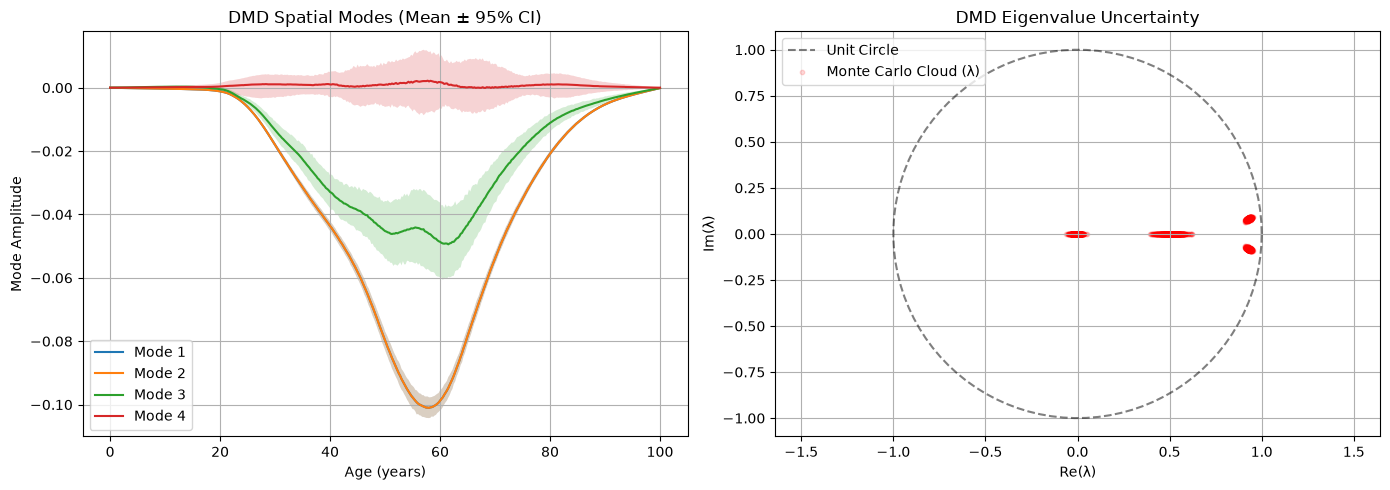

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pydmd import DMD

# 1. Load data
file_path = "data/alcoholData_TotalPopulation.xls"
df_lambda = pd.read_excel(file_path, sheet_name="Lambda_by_Age_Year", index_col=0)

lambda_cols = [c for c in df_lambda.columns if 'Lambda_' in c and 'Std' not in c]
std_cols = [c for c in df_lambda.columns if 'LambdaStd_' in c]

X_mean = df_lambda[lambda_cols].values  # Mean Matrix (401, 20)
X_std = df_lambda[std_cols].values      # Standard Deviation Matrix (401, 20)
ages = df_lambda.index.values

# 2. Initial configuration
n_sims = 1000
svd_rank = 4
n_ages, n_years = X_mean.shape

# 3. BASELINE (Calculated once outside the loop)
dmd_base = DMD(svd_rank=svd_rank, exact=True)
dmd_base.fit(X_mean)
base_modes = np.real(dmd_base.modes)
base_eigs = dmd_base.eigs

# Structures to store Monte Carlo results
all_modes = np.zeros((n_sims, n_ages, svd_rank))
all_eigs = np.zeros((n_sims, svd_rank), dtype=complex)

# 4. Corrected Monte Carlo loop
np.random.seed(42)
for k in range(n_sims):
    # Generate stochastic surface
    X_sample = np.random.normal(loc=X_mean, scale=X_std)
    X_sample = np.maximum(X_sample, 0.0)  # Truncate to >= 0

    # Fit DMD TO EACH SAMPLE
    dmd = DMD(svd_rank=svd_rank, exact=True)
    dmd.fit(X_sample)

    current_modes = np.real(dmd.modes)
    current_eigs = dmd.eigs

    # Match by similarity (resolves permutation and sign alignment)
    matched_modes = np.zeros_like(current_modes)
    matched_eigs = np.zeros_like(current_eigs)
    used_indices = set()

    for j in range(svd_rank):
        # Find the sample mode with the highest alignment to baseline mode j
        dots = [
            np.abs(np.dot(current_modes[:, m], base_modes[:, j])) if m not in used_indices else -1
            for m in range(svd_rank)
        ]
        best_m = np.argmax(dots)
        used_indices.add(best_m)

        mode_j = current_modes[:, best_m].copy()
        
        # Correct sign direction
        if np.dot(mode_j, base_modes[:, j]) < 0:
            mode_j *= -1

        matched_modes[:, j] = mode_j
        matched_eigs[j] = current_eigs[best_m]

    all_modes[k, :, :] = matched_modes
    all_eigs[k, :] = matched_eigs

# 5. Summary statistics (Mean and 95% Confidence Interval)
modes_mean = np.mean(all_modes, axis=0)
modes_p025 = np.percentile(all_modes, 2.5, axis=0)
modes_p975 = np.percentile(all_modes, 97.5, axis=0)

# 6. Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Spatial Modes with 95% Confidence Bands
for i in range(svd_rank):
    axes[0].plot(ages, modes_mean[:, i], label=f"Mode {i+1}")
    axes[0].fill_between(ages, modes_p025[:, i], modes_p975[:, i], alpha=0.2)

axes[0].set_title("DMD Spatial Modes (Mean ± 95% CI)")
axes[0].set_xlabel("Age (years)")
axes[0].set_ylabel("Mode Amplitude")
axes[0].legend()
axes[0].grid(True)

# Plot 2: Monte Carlo Eigenvalue Cloud
theta = np.linspace(0, 2 * np.pi, 100)
axes[1].plot(np.cos(theta), np.sin(theta), "k--", alpha=0.5, label="Unit Circle")
axes[1].scatter(
    np.real(all_eigs.flatten()),
    np.imag(all_eigs.flatten()),
    c="red", alpha=0.15, s=10, label="Monte Carlo Cloud (λ)"
)

axes[1].set_title("DMD Eigenvalue Uncertainty")
axes[1].set_xlabel("Re(λ)")
axes[1].set_ylabel("Im(λ)")
axes[1].axis("equal")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("results/dmd_total_modes.png")
plt.show()

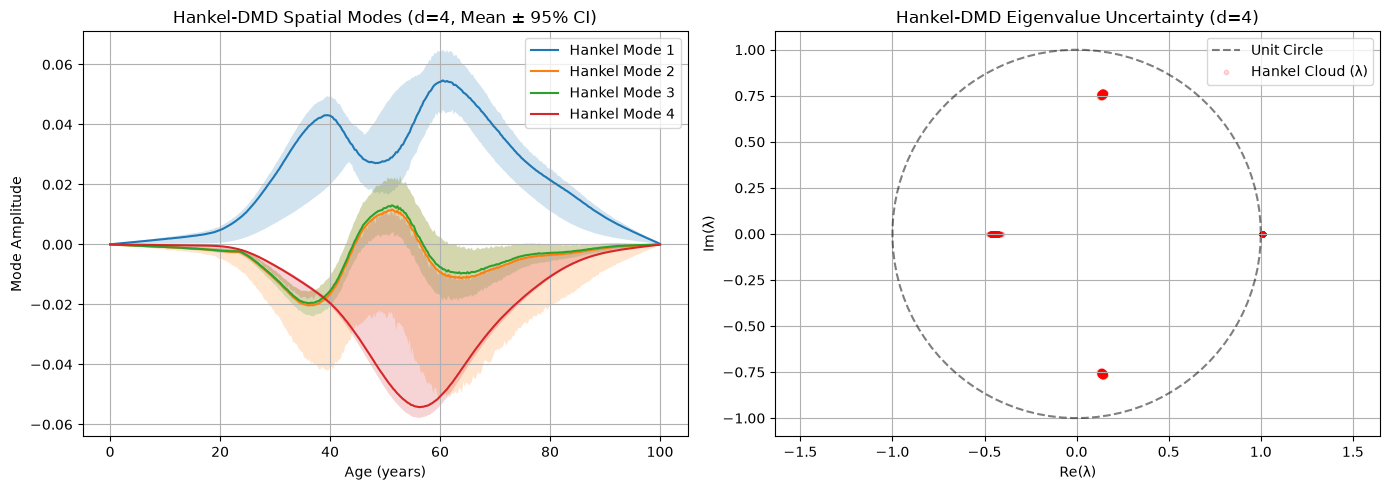

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pydmd import HankelDMD

# 1. Load data
file_path = "data/alcoholData_TotalPopulation.xls"
df_lambda = pd.read_excel(file_path, sheet_name="Lambda_by_Age_Year", index_col=0)

lambda_cols = [c for c in df_lambda.columns if 'Lambda_' in c and 'Std' not in c]
std_cols = [c for c in df_lambda.columns if 'LambdaStd_' in c]

X_mean = df_lambda[lambda_cols].values  # Mean Matrix (401, 20)
X_std = df_lambda[std_cols].values      # Standard Deviation Matrix (401, 20)
ages = df_lambda.index.values

# 2. Initial configuration
n_sims = 1000
svd_rank = 4
d_delay = 4  # Time delay (3 years)
n_ages, n_years = X_mean.shape

# 3. HANKEL-DMD BASELINE
dmd_base = HankelDMD(svd_rank=svd_rank, d=d_delay, exact=True)
dmd_base.fit(X_mean)
# Trim the first 401 rows to project onto the physical age variable
base_modes = np.real(dmd_base.modes[:n_ages, :])
base_eigs = dmd_base.eigs

# Structures to store Monte Carlo results
all_modes = np.zeros((n_sims, n_ages, svd_rank))
all_eigs = np.zeros((n_sims, svd_rank), dtype=complex)

# 4. Monte Carlo loop
np.random.seed(42)
for k in range(n_sims):
    # Generate stochastic surface
    X_sample = np.random.normal(loc=X_mean, scale=X_std)
    X_sample = np.maximum(X_sample, 0.0)  # Truncate to >= 0

    # Fit HankelDMD to sample
    dmd = HankelDMD(svd_rank=svd_rank, d=d_delay, exact=True)
    dmd.fit(X_sample)

    # Extract modes trimmed to the 401 physical ages
    current_modes = np.real(dmd.modes[:n_ages, :])
    current_eigs = dmd.eigs

    # Match by similarity
    matched_modes = np.zeros_like(current_modes)
    matched_eigs = np.zeros_like(current_eigs)
    used_indices = set()

    for j in range(svd_rank):
        dots = [
            np.abs(np.dot(current_modes[:, m], base_modes[:, j])) if m not in used_indices else -1
            for m in range(svd_rank)
        ]
        best_m = np.argmax(dots)
        used_indices.add(best_m)

        mode_j = current_modes[:, best_m].copy()
        
        # Correct sign direction
        if np.dot(mode_j, base_modes[:, j]) < 0:
            mode_j *= -1

        matched_modes[:, j] = mode_j
        matched_eigs[j] = current_eigs[best_m]

    all_modes[k, :, :] = matched_modes
    all_eigs[k, :] = matched_eigs

# 5. Statistics (Mean and 95% Confidence Interval)
modes_mean = np.mean(all_modes, axis=0)
modes_p025 = np.percentile(all_modes, 2.5, axis=0)
modes_p975 = np.percentile(all_modes, 97.5, axis=0)

# 6. Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Hankel-DMD Spatial Modes with Confidence Bands
for i in range(svd_rank):
    axes[0].plot(ages, modes_mean[:, i], label=f"Hankel Mode {i+1}")
    axes[0].fill_between(ages, modes_p025[:, i], modes_p975[:, i], alpha=0.2)

axes[0].set_title(f"Hankel-DMD Spatial Modes (d={d_delay}, Mean ± 95% CI)")
axes[0].set_xlabel("Age (years)")
axes[0].set_ylabel("Mode Amplitude")
axes[0].legend()
axes[0].grid(True)

# Plot 2: Hankel-DMD Monte Carlo Eigenvalue Cloud
theta = np.linspace(0, 2 * np.pi, 100)
axes[1].plot(np.cos(theta), np.sin(theta), "k--", alpha=0.5, label="Unit Circle")
axes[1].scatter(
    np.real(all_eigs.flatten()),
    np.imag(all_eigs.flatten()),
    c="red", alpha=0.15, s=10, label="Hankel Cloud (λ)"
)

axes[1].set_title(f"Hankel-DMD Eigenvalue Uncertainty (d={d_delay})")
axes[1].set_xlabel("Re(λ)")
axes[1].set_ylabel("Im(λ)")
axes[1].axis("equal")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("results/hankel_dmd_total_modes.png")
plt.show()

Running 1000 Monte Carlo simulations in parallel...



Monte Carlo Progress: 100%|██████████| 1000/1000 [00:35<00:00, 27.86it/s]


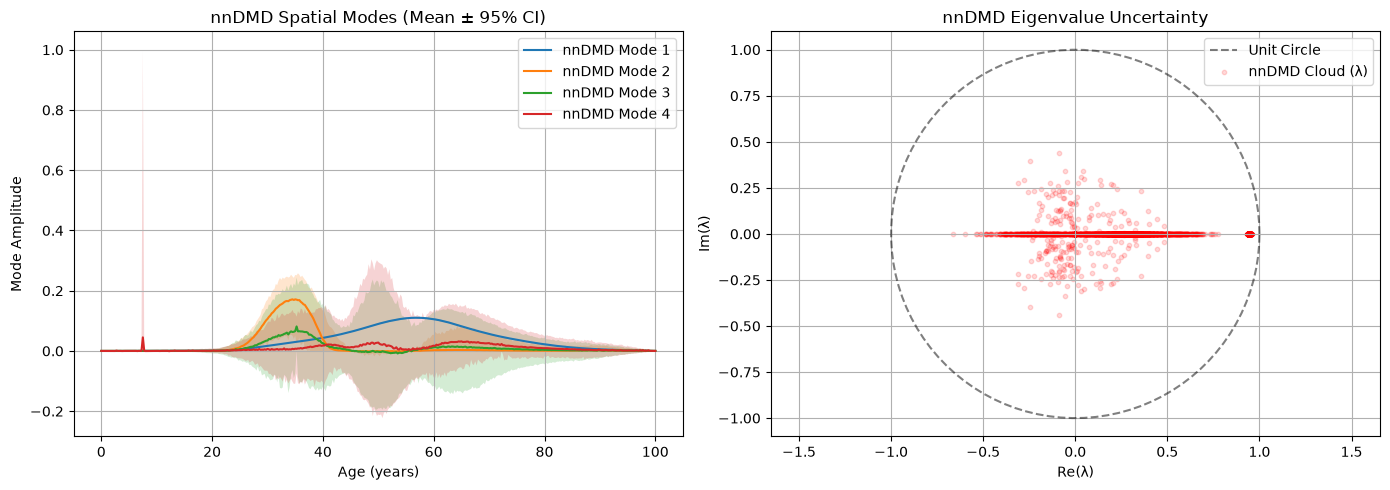

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import nnls
from joblib import Parallel, delayed
from tqdm import tqdm

# 1. Load data
file_path = "data/alcoholData_TotalPopulation.xls"
df_lambda = pd.read_excel(file_path, sheet_name="Lambda_by_Age_Year", index_col=0)

lambda_cols = [c for c in df_lambda.columns if 'Lambda_' in c and 'Std' not in c]
std_cols = [c for c in df_lambda.columns if 'LambdaStd_' in c]

X_mean = df_lambda[lambda_cols].values  # Mean Matrix (401, 20)
X_std = df_lambda[std_cols].values      # Standard Deviation Matrix (401, 20)
ages = df_lambda.index.values

# 2. Initial configuration
n_sims = 1000
svd_rank = 4
n_ages, n_years = X_mean.shape

# Helper function to fit nnDMD
def fit_nndmd(X_data, r=4):
    X1 = X_data[:, :-1]
    X2 = X_data[:, 1:]
    n = X_data.shape[0]
    
    A_nn = np.zeros((n, n))
    X1_T = X1.T
    for i in range(n):
        sol, _ = nnls(X1_T, X2[i, :])
        A_nn[i, :] = sol
        
    all_eigs, all_modes = np.linalg.eig(A_nn)
    idx = np.argsort(np.abs(all_eigs))[::-1][:r]
    return all_eigs[idx], all_modes[:, idx]

# 3. BASELINE nnDMD (Calculated outside the loop)
base_eigs, base_modes_complex = fit_nndmd(X_mean, r=svd_rank)
base_modes = np.real(base_modes_complex)

# 4. Worker function for a single simulation (for parallel execution)
def run_single_simulation(k, X_mean, X_std, base_modes, svd_rank):
    # Independent seed per thread to ensure parallel randomness
    np.random.seed(42 + k)
    
    # Generate stochastic surface N(mu, sigma)
    X_sample = np.random.normal(loc=X_mean, scale=X_std)
    X_sample = np.maximum(X_sample, 0.0)  # Truncate to >= 0

    # Fit nnDMD
    current_eigs, current_modes_complex = fit_nndmd(X_sample, r=svd_rank)
    current_modes = np.real(current_modes_complex)

    # Match by similarity (permutation and sign alignment)
    matched_modes = np.zeros_like(current_modes)
    matched_eigs = np.zeros_like(current_eigs)
    used_indices = set()

    for j in range(svd_rank):
        dots = [
            np.abs(np.dot(current_modes[:, m], base_modes[:, j])) if m not in used_indices else -1
            for m in range(svd_rank)
        ]
        best_m = np.argmax(dots)
        used_indices.add(best_m)

        mode_j = current_modes[:, best_m].copy()
        if np.dot(mode_j, base_modes[:, j]) < 0:
            mode_j *= -1

        matched_modes[:, j] = mode_j
        matched_eigs[j] = current_eigs[best_m]

    return matched_modes, matched_eigs

# 5. Parallel Execution with Progress Bar (tqdm)
print("Running 1000 Monte Carlo simulations in parallel...")
results = Parallel(n_jobs=-1)(
    delayed(run_single_simulation)(k, X_mean, X_std, base_modes, svd_rank)
    for k in tqdm(range(n_sims), desc="Monte Carlo Progress")
)

# 6. Reconstruct global arrays
all_modes = np.zeros((n_sims, n_ages, svd_rank))
all_eigs = np.zeros((n_sims, svd_rank), dtype=complex)

for k, (m_modes, m_eigs) in enumerate(results):
    all_modes[k, :, :] = m_modes
    all_eigs[k, :] = m_eigs

# 7. Summary statistics (Mean and 95% Confidence Interval)
modes_mean = np.mean(all_modes, axis=0)
modes_p025 = np.percentile(all_modes, 2.5, axis=0)
modes_p975 = np.percentile(all_modes, 97.5, axis=0)

# 8. Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: nnDMD Spatial Modes
for i in range(svd_rank):
    axes[0].plot(ages, modes_mean[:, i], label=f"nnDMD Mode {i+1}")
    axes[0].fill_between(ages, modes_p025[:, i], modes_p975[:, i], alpha=0.2)

axes[0].set_title("nnDMD Spatial Modes (Mean ± 95% CI)")
axes[0].set_xlabel("Age (years)")
axes[0].set_ylabel("Mode Amplitude")
axes[0].legend()
axes[0].grid(True)

# Plot 2: nnDMD Eigenvalue Cloud
theta = np.linspace(0, 2 * np.pi, 100)
axes[1].plot(np.cos(theta), np.sin(theta), "k--", alpha=0.5, label="Unit Circle")
axes[1].scatter(
    np.real(all_eigs.flatten()),
    np.imag(all_eigs.flatten()),
    c="red", alpha=0.15, s=10, label="nnDMD Cloud (λ)"
)

axes[1].set_title("nnDMD Eigenvalue Uncertainty")
axes[1].set_xlabel("Re(λ)")
axes[1].set_ylabel("Im(λ)")
axes[1].axis("equal")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("results/nn_dmd_total_modes.png")
plt.show()